## Task 6: House Price Prediction
##  Problem Statement

The goal is to build a regression model that predicts house prices based on property features such as:

Square footage

Number of bedrooms

Number of bathrooms

Location and other attributes

This is a supervised regression problem.

## 1. Import Libraries

In [23]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# 2. Load Dataset

In [24]:
# Load dataset (update path as needed)
df = pd.read_csv("kc_house_data.csv")

# Preview
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


## Dataset Overview

In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


## Check Missing Values

In [26]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

# 3. Data Preprocessing
# Handle Missing Values

In [27]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17044\3880280569.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


## Encode Categorical Features

In [28]:
# One-hot encoding for location and other categorical features
df = pd.get_dummies(df, drop_first=True)
df

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,date_20150508T000000,date_20150509T000000,date_20150510T000000,date_20150511T000000,date_20150512T000000,date_20150513T000000,date_20150514T000000,date_20150515T000000,date_20150524T000000,date_20150527T000000
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,False,False,False,False,False,False,False,False,False,False
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
21609,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
21610,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False
21611,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,False,False,False,False,False,False,False,False,False,False


# 4. Exploratory Data Analysis (EDA)
# Price Distribution

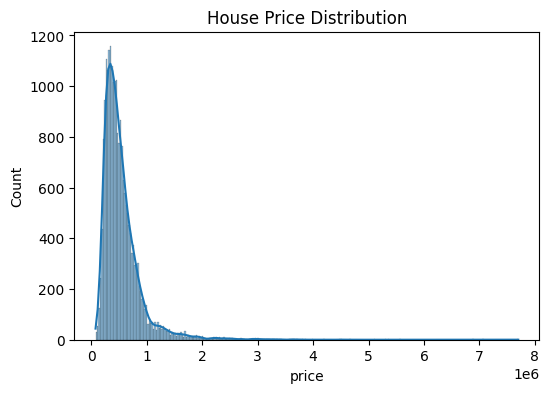

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title("House Price Distribution")
plt.show()

## Correlation Heatmap

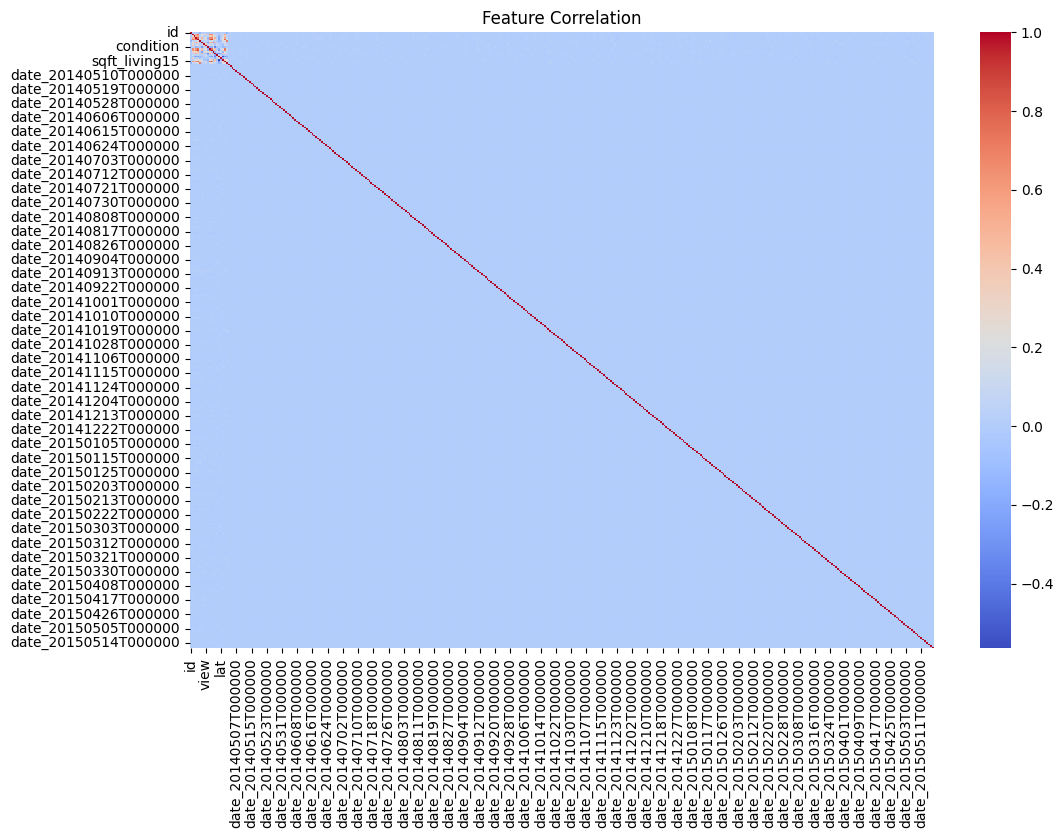

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Key Feature Relationships

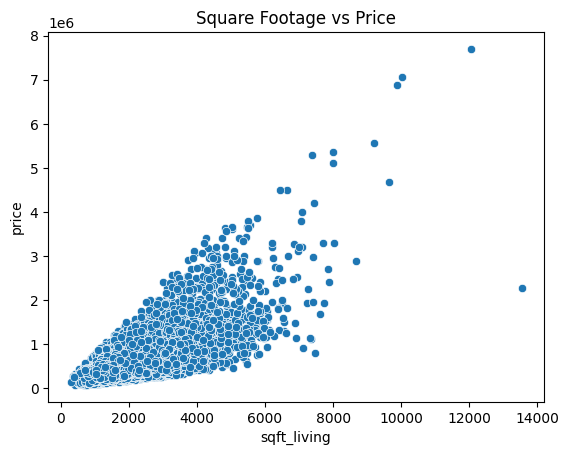

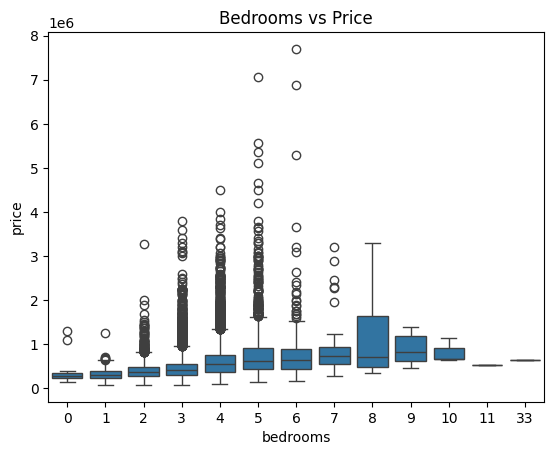

In [31]:
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Square Footage vs Price")
plt.show()

sns.boxplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price")
plt.show()

# 5. Feature Selection

In [32]:
# Target variable
y = df['price']

# Features
X = df.drop('price', axis=1)

## 6. Train-Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Feature Scaling
# (Important for Linear Regression)

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Model Training
#  Model 1: Linear Regression

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# Model 2: Gradient Boosting

In [36]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

# 9. Model Evaluation
# Define Evaluation Function

In [37]:
def evaluate_model(y_true, y_pred, model_name):
    r2=r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"📊 {model_name}")
    print(f"r2_score : {r2:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-"*30)

# Evaluate Both Models

In [38]:
evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, gb_pred, "Gradient Boosting")

📊 Linear Regression
r2_score : 0.70
MAE : 129193.84
RMSE: 214186.32
------------------------------
📊 Gradient Boosting
r2_score : 0.85
MAE : 81061.16
RMSE: 149531.78
------------------------------


# 10. Actual vs Predicted Visualization
# Linear Regression Plot

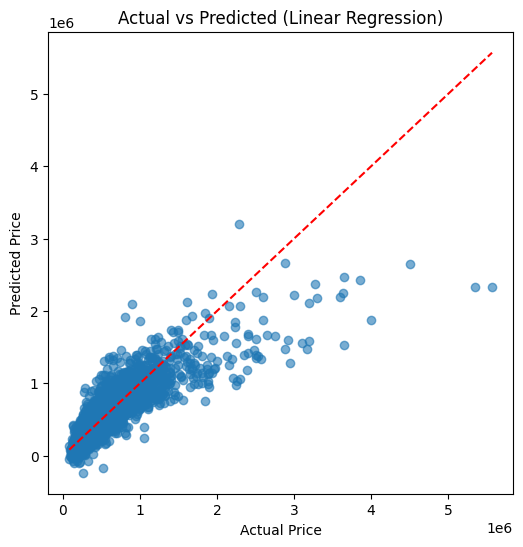

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

# Gradient Boosting Plot

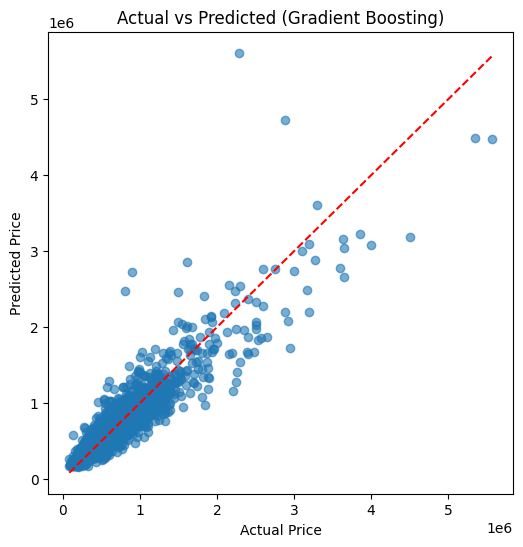

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, gb_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

# 11. Feature Importance (Gradient Boosting)

# Typical Important Features

# (Your results may vary)

# Square footage

# Location

# Bathrooms

# Bedrooms

# Year built

# 12. Final Insights
 # Key Findings

House price strongly depends on living area (sqft)

Location-related features significantly impact price

Gradient Boosting usually outperforms Linear Regression

Feature scaling improves linear model performance

# Model Performance Interpretation

MAE → average prediction error in price units

RMSE → penalizes large errors more heavily

Lower values indicate better model performance